## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [1]:
!hostname

ne1dg6-009.nygenome.org


In [2]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from mord import OrdinalRidge  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch 

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
import LeafletFA_utilities
importlib.reload(LeafletFA_utilities)

# Import functions from utilities.py 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
from LeafletFA_utilities import *

# check if using cuda device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import waypoints as wayp
importlib.reload(wayp)

# Add path to where find_intron_clusters_v3.py is located 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering')
from find_intron_clusters_v3 import JunctionReader

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

!hostname

Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0
cuda
Using device: cuda
ne1dg6-009.nygenome.org


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


### Specify if we want to prep brain only file or ALL tissue file


In [3]:
input_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/junction_processing_20250223/anndatas/merged_anndata.h5ad"
splice_adata = ad.read_h5ad(input_file)
print(f"The number of cells in the dataset is {splice_adata.shape[0]}")

The number of cells in the dataset is 9921


In [4]:
ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/ATSEfiles/TMS_atse_file_unanno_also_2025-03-03_15-00-44.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")

In [5]:
splice_adata.obs.Type.value_counts()

Type
3mo            2437
APOE4_TREM2    2098
6mo            2089
21mo           1728
5xFAD          1569
Name: count, dtype: int64

#### Figure out which junctions to include for model training object

In [6]:
splice_adata.var["non_zero_count_cells"] = np.array((splice_adata.X > 0).sum(axis=0)).flatten()
splice_adata.var["non_zero_cell_prop"] = splice_adata.var["non_zero_count_cells"] / splice_adata.shape[0]

In [7]:
splice_adata.var

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,non_zero_count_cells,non_zero_cell_prop
0,chr10_103204014_103224757_+,ATSE_3146,GT-AG,five_prime,Slc6a15,ENSMUSG00000019894.15,2,0.0,NaN,29,0,28,0.002822
1,chr10_103204014_103224887_+,ATSE_3146,GT-AG,both,Slc6a15,ENSMUSG00000019894.15,2,0.0,1.0,114,1,108,0.010886
2,chr10_105090770_105107359_-,ATSE_4515,GT-AG,both,Tmtc2,ENSMUSG00000036019.9,3,1.0,0.0,130,2,119,0.011995
3,chr10_105090770_105139454_-,ATSE_4515,GT-AG,both,Tmtc2,ENSMUSG00000036019.9,3,1.0,0.0,30,3,26,0.002621
4,chr10_105107441_105139454_-,ATSE_4515,GT-AG,both,Tmtc2,ENSMUSG00000036019.9,3,1.0,0.0,99,4,95,0.009576
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15972,chrY_1263700_1263795_-,ATSE_2899,GT-AG,both,Ddx3y,ENSMUSG00000069045.12,2,1.0,0.0,124,15972,113,0.011390
15973,chrY_90804686_90827617_+,ATSE_5615,GT-AG,both,Gm47283,ENSMUSG00000096768.9,2,0.0,1.0,821,15973,602,0.060679
15974,chrY_90804949_90827617_+,ATSE_5615,GT-AG,both,Gm47283,ENSMUSG00000096768.9,2,0.0,1.0,322,15974,250,0.025199
15975,chrY_927439_927602_+,ATSE_4808,GT-AG,five_prime,Kdm5d,ENSMUSG00000056673.15,2,0.0,NaN,63,15975,61,0.006149


In [8]:
# let's make an ATSE event id score to decide which ATSEs to keep at the end, since we are limited to under 100,000 splice junctions 
# what do we care about? 
# - number of fully annotated splice junctions in the ATSE vs partially annotated vs unannotated (annotation_status)
# - number of cells that have splice junctions in this ATSE expressed above zero (non_zero_cell_prop)
# - which splice_motif is used in the ATSE (splice_motif)

# let's make a score for each ATSE based on these three criteria 
# - annotation_status: 1 for fully annotated, 0.5 for partially annotated, 0 for unannotated
# - non_zero_cell_prop: 1 if non_zero_cell_prop > 0.01, 0 otherwise
# - splice_motif: 1 if splice_motif is "GT-AG", 0 otherwise

# let's calculate these for every junction and combine and normalize score per ATSE event_id 
splice_adata.var["annotation_status_score"] = splice_adata.var["annotation_status"].map({"both": 1, "five_prime": 0.5, "three_prime": 0.5, "unannotated": 0})
splice_adata.var["non_zero_cell_prop_score"] = (splice_adata.var["non_zero_cell_prop"] > 0.01).astype(int)
splice_adata.var["splice_motif_score"] = (splice_adata.var["splice_motif"] == "GT-AG").astype(int)

# weigh the annotation_status_score more heavily than the other two scores 
splice_adata.var["annotation_status_score"] *= 2
splice_adata.var["non_zero_cell_prop_score"] *= 1.5

# Combine and normalize score per ATSE event_id 
# First group by event_id and sum the scores before normalizing by the number of junctions in the event_id
atse_scores = splice_adata.var.groupby("event_id")[
    ["annotation_status_score", "non_zero_cell_prop_score"]
].sum()

# Normalize by the number of junctions in each event_id
junction_counts = splice_adata.var["event_id"].value_counts().rename("junction_count")

# Add the three columns to make ATSE_score 
atse_scores["atse_score"] = atse_scores.sum(axis=1)
atse_scores["number_of_junctions"] = junction_counts
atse_scores["normalized_atse_score"] = atse_scores["atse_score"] / junction_counts
atse_scores.sort_values("number_of_junctions", ascending=False).head()

/scratch/ipykernel_1989371/4098449752.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  atse_scores = splice_adata.var.groupby("event_id")[


,annotation_status_score,non_zero_cell_prop_score,atse_score,number_of_junctions,normalized_atse_score
event_id,,,,,
ATSE_929,37.0,31.5,68.5,29,2.362069
ATSE_3126,10.0,9.0,19.0,13,1.461538
ATSE_1264,17.0,13.5,30.5,11,2.772727
ATSE_1091,16.0,12.0,28.0,10,2.800000
ATSE_3741,19.0,6.0,25.0,10,2.500000


In [9]:
atse_scores

,annotation_status_score,non_zero_cell_prop_score,atse_score,number_of_junctions,normalized_atse_score
event_id,,,,,
ATSE_0,10.0,0.0,10.0,5,2.00
ATSE_1,3.0,1.5,4.5,2,2.25
ATSE_2,3.0,1.5,4.5,2,2.25
ATSE_3,4.0,3.0,7.0,2,3.50
ATSE_4,6.0,3.0,9.0,3,3.00
...,...,...,...,...,...
ATSE_6080,4.0,0.0,4.0,2,2.00
ATSE_6081,2.0,0.0,2.0,2,1.00
ATSE_6082,2.0,0.0,2.0,2,1.00


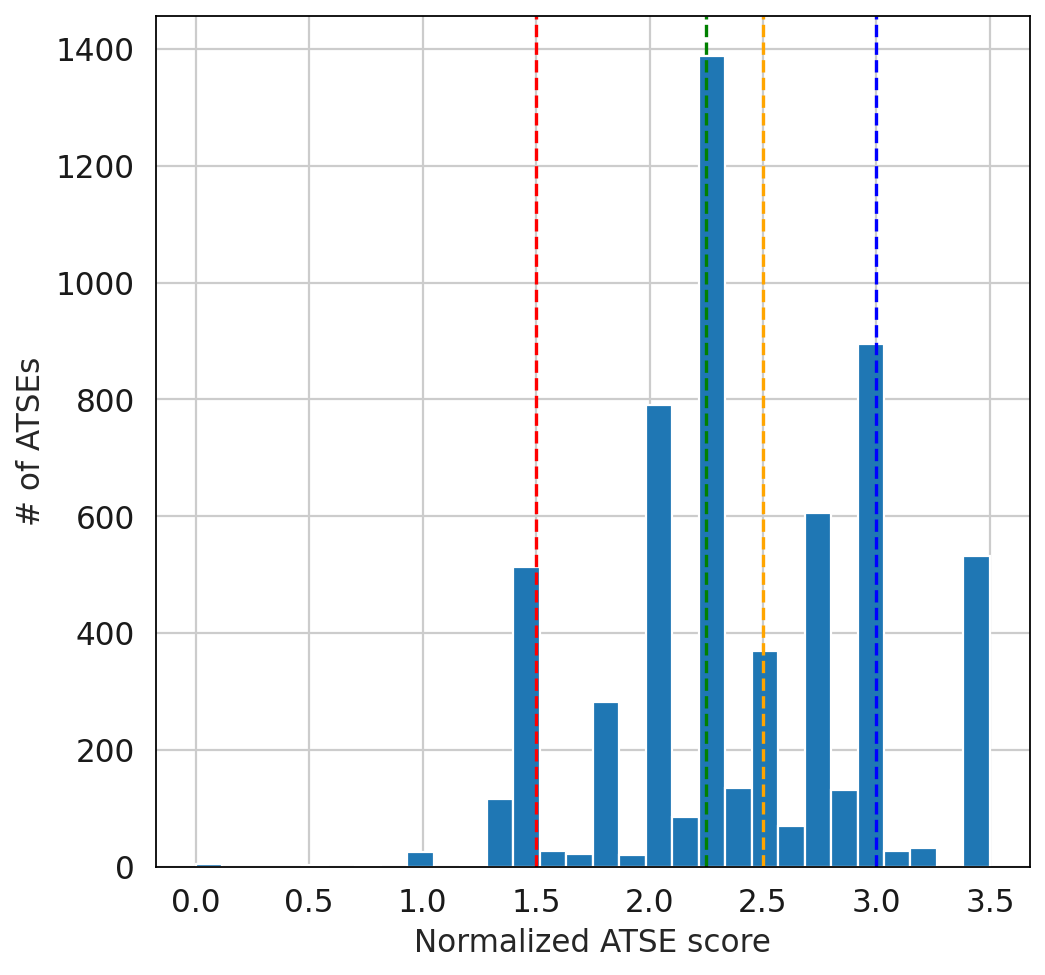

Number of ATSEs remaining at 10th percentile: 5412
Number of ATSEs remaining at 50th percentile: 2819
Number of ATSEs remaining at 60th percentile: 2295
Number of ATSEs remaining at 75th percentile: 1485


In [10]:
# summarize histogram of normalized_atse_score show percentilues 10% 50% 90% 
atse_scores["normalized_atse_score"].describe(percentiles=[0.1, 0.5, 0.6, 0.9])
# make a histogram of the normalized_atse_score 
atse_scores["normalized_atse_score"].hist(bins=30)

# draw dashed lines for the percentiles 
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.1), color="red", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.5), color="green", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.6), color="orange", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.9), color="blue", linestyle="--")

# add xlaxis and yaxis labels 
plt.xlabel("Normalized ATSE score")
plt.ylabel("# of ATSEs")
plt.show()

# Print how many ATSEs remain after filtering at each of the percentiles
print(f"Number of ATSEs remaining at 10th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.1)].shape[0]}")
print(f"Number of ATSEs remaining at 50th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.5)].shape[0]}")
print(f"Number of ATSEs remaining at 60th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.6)].shape[0]}")
print(f"Number of ATSEs remaining at 75th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.75)].shape[0]}")


In [11]:
# For splice_adata object, let's filter out the ATSEs that have a normalized_atse_score below the 10th percentile
atse_scores_filt = atse_scores[atse_scores["normalized_atse_score"] > atse_scores["normalized_atse_score"].quantile(0.15)]
splice_adata = splice_adata[:, splice_adata.var["event_id"].isin(atse_scores_filt.index)]

In [12]:
# find common columns between splice_adata.var and atses
splice_adata.var = splice_adata.var.merge(atses[["gene_id", "gene_name", "junction_id", "annotation_status", "position_off_5_prime", "position_off_3_prime", "transcripts", "transcript_types"]], on=["junction_id", "gene_id", "annotation_status", "gene_name", "position_off_5_prime", "position_off_3_prime"])

In [13]:
splice_adata.var.reset_index(drop=True, inplace=True)
# Rename the old junction_id_index to old_junction_id_index 
splice_adata.var.rename(columns={'junction_id_index': 'old_junction_id_index'}, inplace=True)
# Redo the junction_id_index column now that we have removed some junctions
splice_adata.var['junction_id_index'] = splice_adata.var.index
splice_adata.var.head()

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,old_junction_id_index,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,transcripts,transcript_types,junction_id_index
0,chr10_103204014_103224757_+,ATSE_3146,GT-AG,five_prime,Slc6a15,ENSMUSG00000019894.15,2,0.0,NaN,29,0,28,0.002822,1.0,0.0,1,ENSMUST00000179636.3,protein_coding,0
1,chr10_103204014_103224887_+,ATSE_3146,GT-AG,both,Slc6a15,ENSMUSG00000019894.15,2,0.0,1.0,114,1,108,0.010886,2.0,1.5,1,ENSMUST00000179636.3,protein_coding,1
2,chr10_105090770_105107359_-,ATSE_4515,GT-AG,both,Tmtc2,ENSMUSG00000036019.9,3,1.0,0.0,130,2,119,0.011995,2.0,1.5,1,ENSMUST00000061506.9,protein_coding,2
3,chr10_105090770_105139454_-,ATSE_4515,GT-AG,both,Tmtc2,ENSMUSG00000036019.9,3,1.0,0.0,30,3,26,0.002621,2.0,0.0,1,ENSMUST00000061506.9,protein_coding,3
4,chr10_105107441_105139454_-,ATSE_4515,GT-AG,both,Tmtc2,ENSMUSG00000036019.9,3,1.0,0.0,99,4,95,0.009576,2.0,0.0,1,ENSMUST00000061506.9,protein_coding,4


In [15]:
# filter the trancsript_types == "lncRNA"
splice_adata.var[splice_adata.var["transcript_types"] == "lncRNA"]  

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,old_junction_id_index,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,transcripts,transcript_types,junction_id_index
271,chr10_39498723_39508945_-,ATSE_5799,GT-AG,both,E130307A14Rik,ENSMUSG00000087177.8,3,1.0,0.0,22,301,22,0.002218,2.0,0.0,1,"ENSMUST00000133302.8,ENSMUST00000129191.8",lncRNA,271
272,chr10_39498723_39515559_-,ATSE_5799,GT-AG,both,E130307A14Rik,ENSMUSG00000087177.8,3,1.0,0.0,25,302,25,0.002520,2.0,0.0,1,"ENSMUST00000129191.8,ENSMUST00000139356.8",lncRNA,272
273,chr10_39509012_39515559_-,ATSE_5799,GT-AG,both,E130307A14Rik,ENSMUSG00000087177.8,3,1.0,0.0,21,303,19,0.001915,2.0,0.0,1,"ENSMUST00000133302.8,ENSMUST00000139356.8",lncRNA,273
467,chr10_72810527_72813471_-,ATSE_6083,GT-AG,both,A330049N07Rik,ENSMUSG00000111994.2,2,1.0,0.0,30,532,25,0.002520,2.0,0.0,1,ENSMUST00000220010.2,lncRNA,467
468,chr10_72810527_72817823_-,ATSE_6083,GT-AG,both,A330049N07Rik,ENSMUSG00000111994.2,2,1.0,0.0,38,533,32,0.003225,2.0,0.0,1,ENSMUST00000220010.2,lncRNA,468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13278,chrX_60178402_60216590_+,ATSE_2879,GT-AG,both,Cdr1os,ENSMUSG00000071753.14,4,0.0,1.0,62,15828,58,0.005846,2.0,0.0,1,ENSMUST00000144853.9,lncRNA,13278
13279,chrX_60178402_60218733_+,ATSE_2879,GT-AG,both,Cdr1os,ENSMUSG00000071753.14,4,0.0,1.0,391,15829,344,0.034674,2.0,1.5,1,ENSMUST00000144853.9,lncRNA,13279
13280,chrX_60216648_60218733_+,ATSE_2879,GT-AG,both,Cdr1os,ENSMUSG00000071753.14,4,0.0,1.0,63,15830,59,0.005947,2.0,0.0,1,ENSMUST00000144853.9,lncRNA,13280
13400,chrY_90804686_90827617_+,ATSE_5615,GT-AG,both,Gm47283,ENSMUSG00000096768.9,2,0.0,1.0,821,15973,602,0.060679,2.0,1.5,1,ENSMUST00000179483.9,lncRNA,13400


### Load in gene expression matrix for RH individual nuclei data and align cell IDs 

### Subset to just cell types with more than 10 cells in them

In [16]:
# Mapping dictionary for cleaned cluster names
cluster_mapping = {
    'Cerebellum_granule_neurons': 'Neurons',
    'Interbrain_and_midbrain_neurons_1': 'Neurons',
    'Interbrain_and_midbrain_neurons_2': 'Neurons',
    'Oligodendrocytes': 'Oligodendrocytes',
    'Cortical_projection_neurons_1': 'Neurons',
    'Astrocytes': 'Astrocytes',
    'Striatal_neurons_1': 'Neurons',
    'Oligodendrocyte_progenitor_cells': 'OPCs',
    'OB_neurons_1': 'Neurons',
    'Interneurons_1': 'Neurons',
    'Cortical_projection_neurons_2': 'Neurons',
    'Cerebellum_interneurons': 'Neurons',
    'Interneurons_2': 'Neurons',
    'Endothelial_cells': 'Endothelial Cells',
    'Microglia': 'Microglia',
    'Dentate_gyrus_neurons': 'Neurons',
    'Bergmann_glia': 'Astrocytes',
    'Purkinje_neurons': 'Neurons',
    'Vascular_leptomeningeal_cells': 'Endothelial Cells',
    'OB_neurons_2': 'Neurons',
    'Choroid_plexus_epithelial_cells': 'Epithelial Cells',
    'Cortical_projection_neurons_3': 'Neurons',
    'Striatal_neurons_2': 'Neurons',
    'Ependymal_cells': 'Ependymal Cells',
    'OB_neurons_3': 'Neurons',
    'Hindbrain_neurons_2': 'Neurons',
    'Hindbrain_neurons_1': 'Neurons',
    'Habenula_neurons': 'Neurons'
}

# Apply mapping to create a new column
splice_adata.obs['Cleaned_cluster_name'] = splice_adata.obs['Main_cluster_name'].map(cluster_mapping)

In [18]:
# Step 1: Count the number of cells per cell type in 'cell_ontology_class'
cell_type_counts = splice_adata.obs['Cleaned_cluster_name'].value_counts()

# Step 2: Filter for cell types with more than 50 cells
cell_types_to_keep = cell_type_counts[cell_type_counts > 10].index

# Step 3: Subset the AnnData object to only include these cell types
splice_adata = splice_adata[splice_adata.obs['Cleaned_cluster_name'].isin(cell_types_to_keep)]

# Print the subsetted cell types and their counts
print(f"The breakdown of the remaining cell types is as follows:\n{splice_adata.obs['Cleaned_cluster_name'].value_counts()}")

The breakdown of the remaining cell types is as follows:
Cleaned_cluster_name
Neurons              7674
Oligodendrocytes      891
Astrocytes            698
OPCs                  250
Endothelial Cells     202
Microglia             141
Epithelial Cells       29
Ependymal Cells        19
Name: count, dtype: int64


### Obtain sparse junction usage ratios! (First filter to keep only junctions with reasonable coverage...)

In [19]:
# Print final number of splice junctions, ATSEs, and genes in splice_adata
print(f"Number of splice junctions: {splice_adata.shape[1]}")
print(f"Number of ATSEs: {splice_adata.var['event_id'].nunique()}")
print(f"Number of genes: {splice_adata.var['gene_id'].nunique()}")

Number of splice junctions: 13402
Number of ATSEs: 5081
Number of genes: 2918


In [20]:
print(splice_adata.var.splice_motif.value_counts())
print(splice_adata.var.annotation_status.value_counts())

splice_motif
GT-AG    13264
GC-AG      138
Name: count, dtype: int64
annotation_status
both           10974
five_prime      1241
three_prime     1181
unannotated        6
Name: count, dtype: int64


In [21]:
# Update junction_counts and cluster_counts
junction_counts = splice_adata.layers["cell_by_junction_matrix"].tocoo()
cluster_counts = splice_adata.layers["cell_by_cluster_matrix"].tocoo()

#### Get sparse PCA, UMAP and Diffusion Map!

In [25]:
from sklearn.decomposition import TruncatedSVD

# Get sparse centered PSI values 
splice_adata.layers["junc_ratio"] = wayp.calculate_centered_psi(junction_counts, cluster_counts)

# Step 1: Perform PCA using sparse data
n_components = 40  

n_iter = 30  # Increasing the number of iterations for better convergence
svd = TruncatedSVD(n_components=n_components, n_iter=n_iter, random_state=42)

# Fit and transform the junction ratio data (this gives U)
U = svd.fit_transform(splice_adata.layers["junc_ratio"])

# Get the singular values (S)
S = svd.singular_values_

# Multiply U by S to get U * S
U_by_S = U * S  # This scales each component in U by the corresponding singular value in S

# Store the PCA results (U * S) in the 'X_pca' field of .obsm (multi-dimensional)
splice_adata.obsm['X_pca'] = U_by_S

# store explained variance ratio for future reference
splice_adata.uns['pca_explained_variance_ratio'] = svd.explained_variance_ratio_

# Step 2: Compute UMAP on the PCA-reduced data
sc.pp.neighbors(splice_adata, use_rep='X_pca')

# Step 3. Calculate UMAP 
sc.tl.umap(splice_adata)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


... storing 'highlight' as categorical


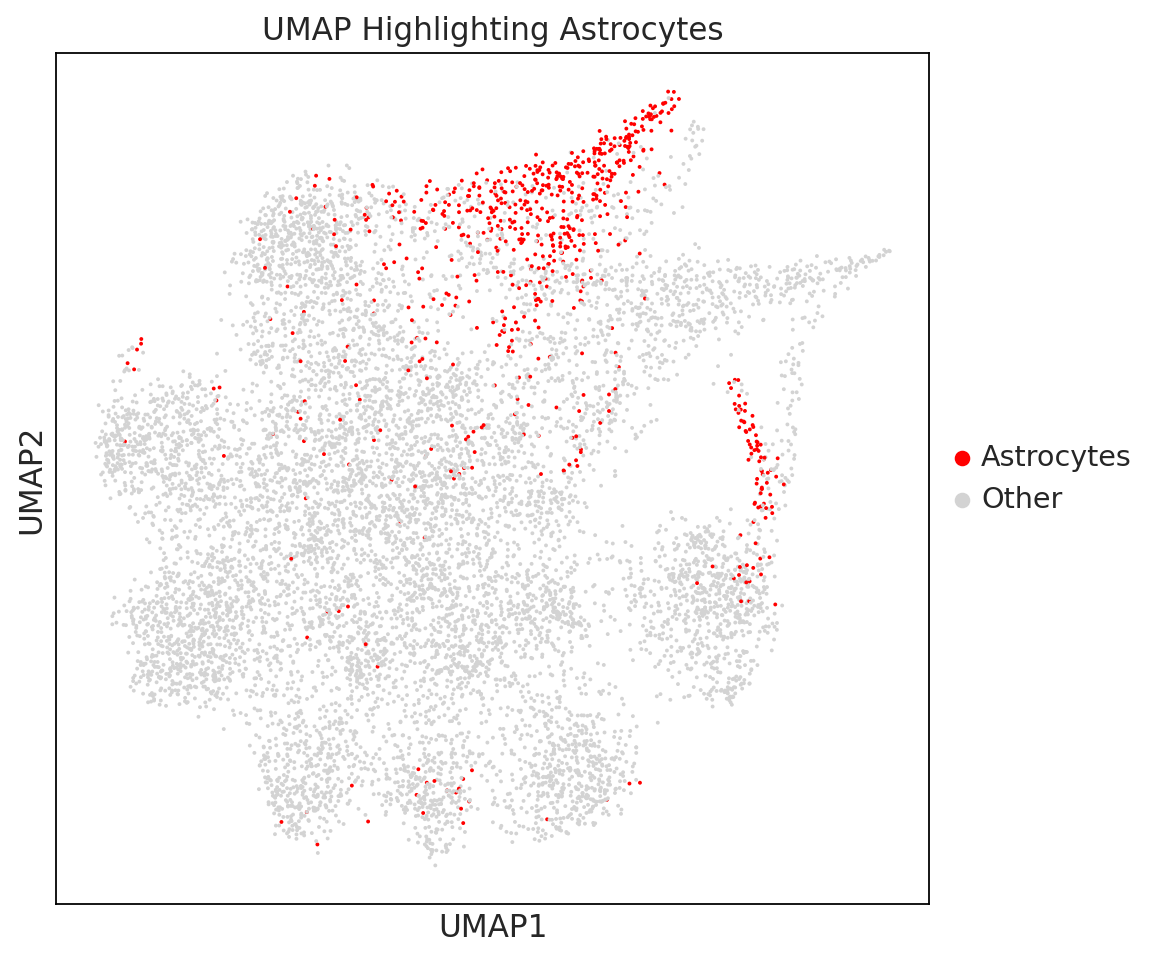

... storing 'highlight' as categorical


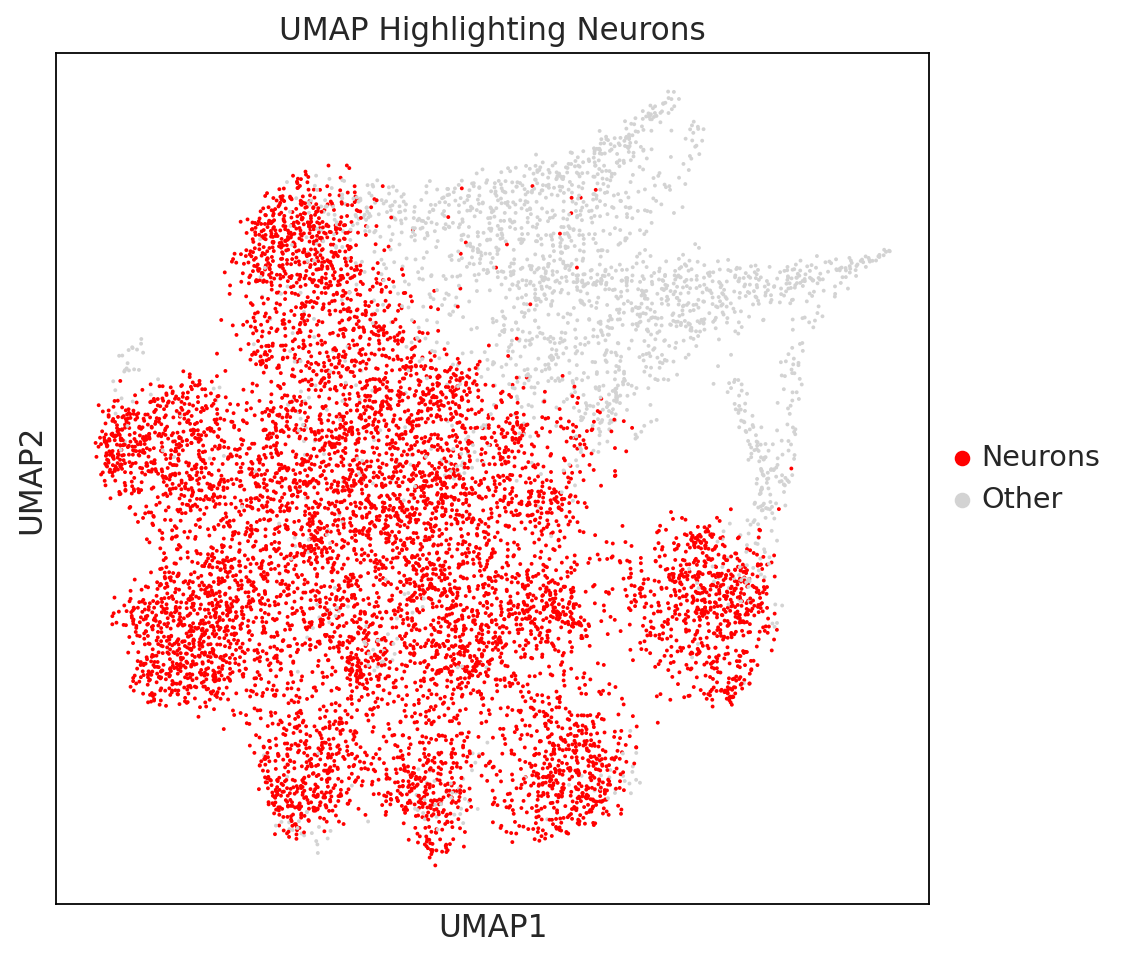

... storing 'highlight' as categorical


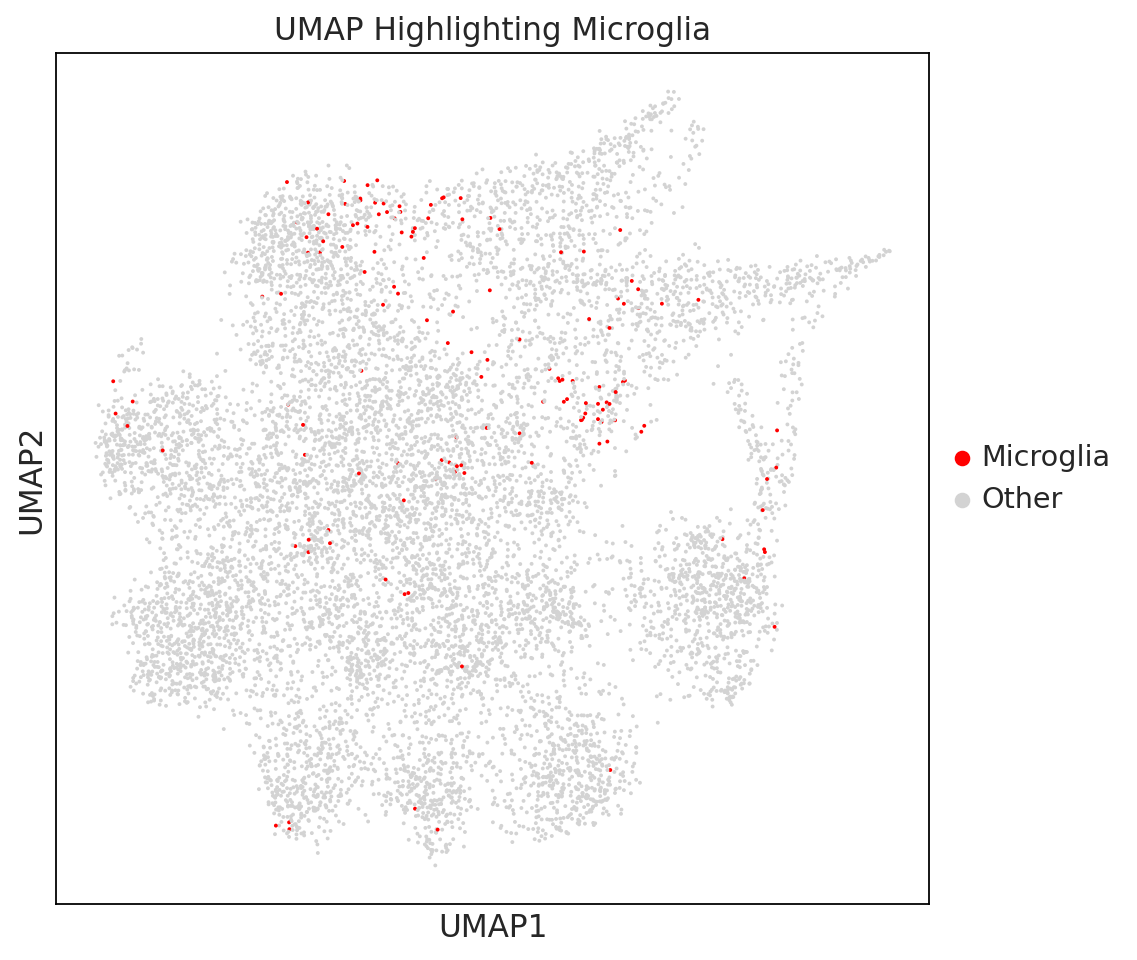

... storing 'highlight' as categorical


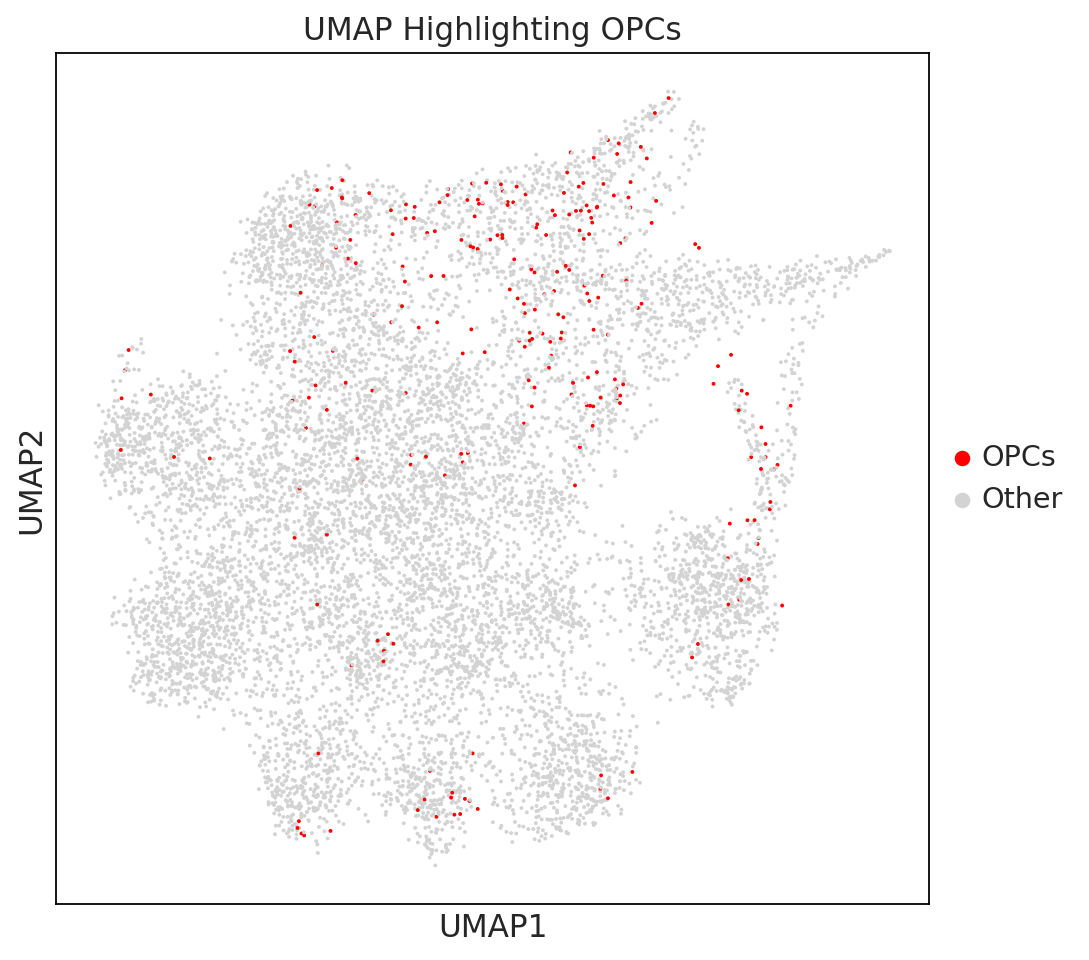

... storing 'highlight' as categorical


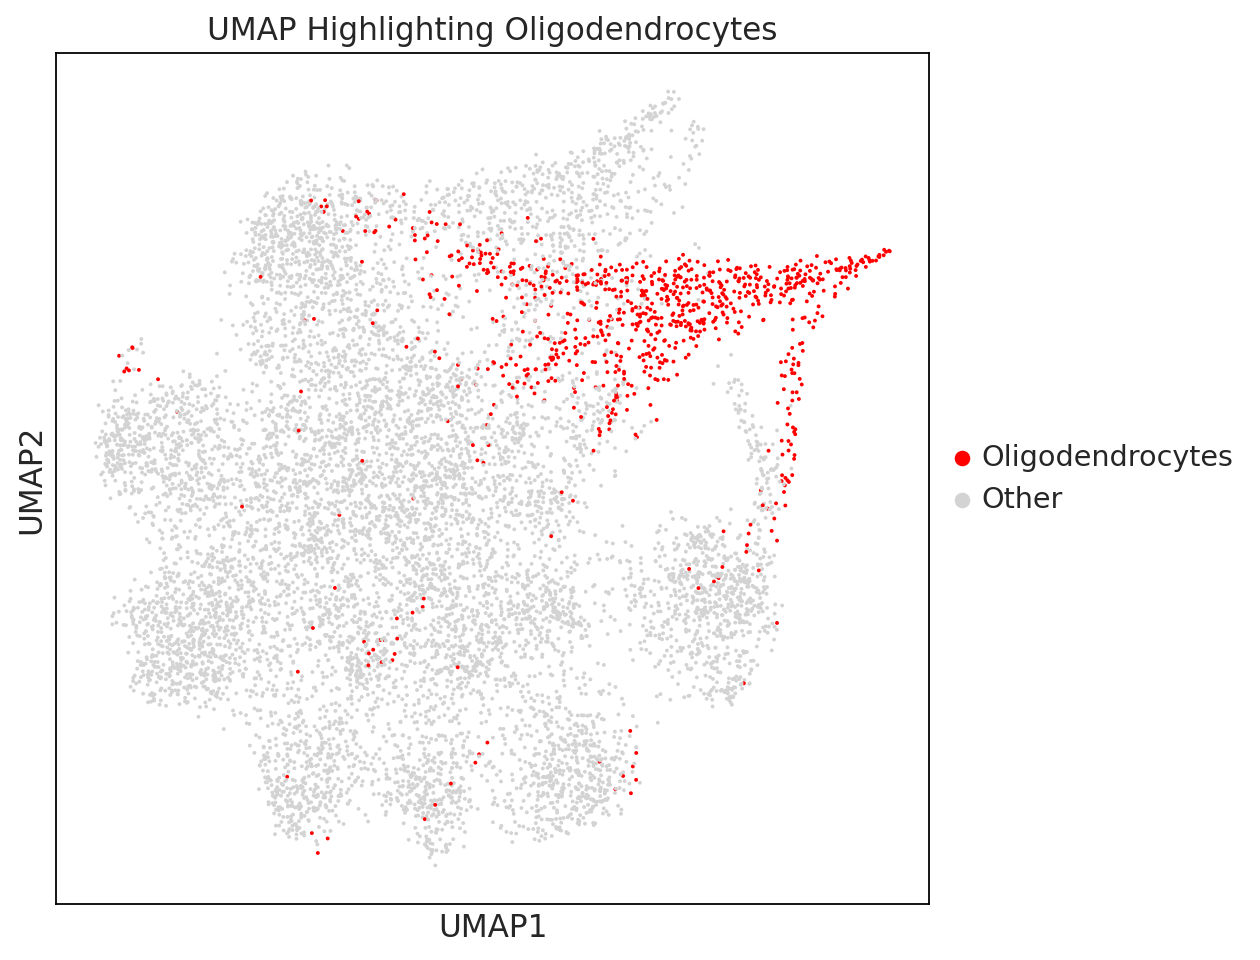

... storing 'highlight' as categorical


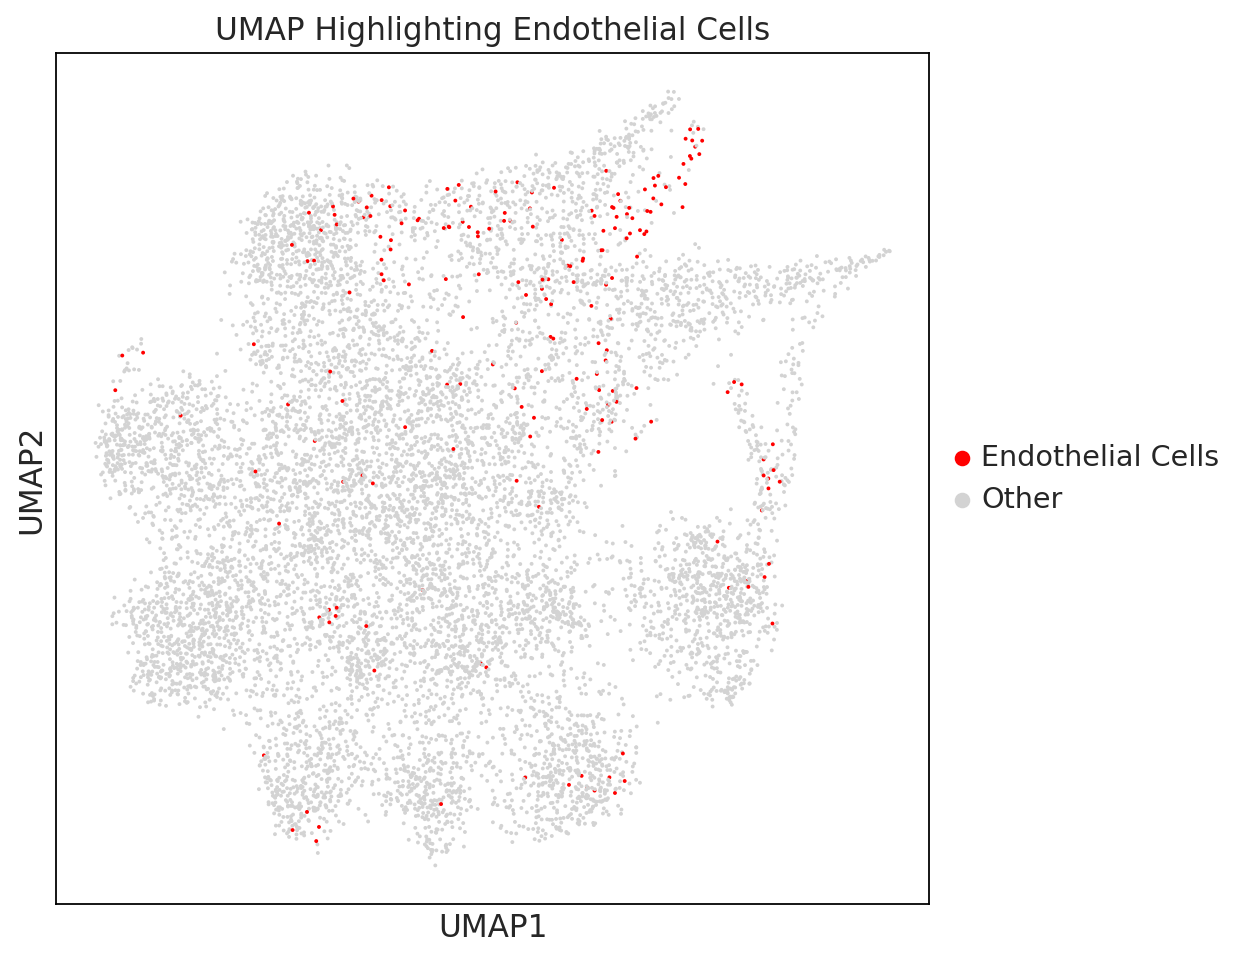

... storing 'highlight' as categorical


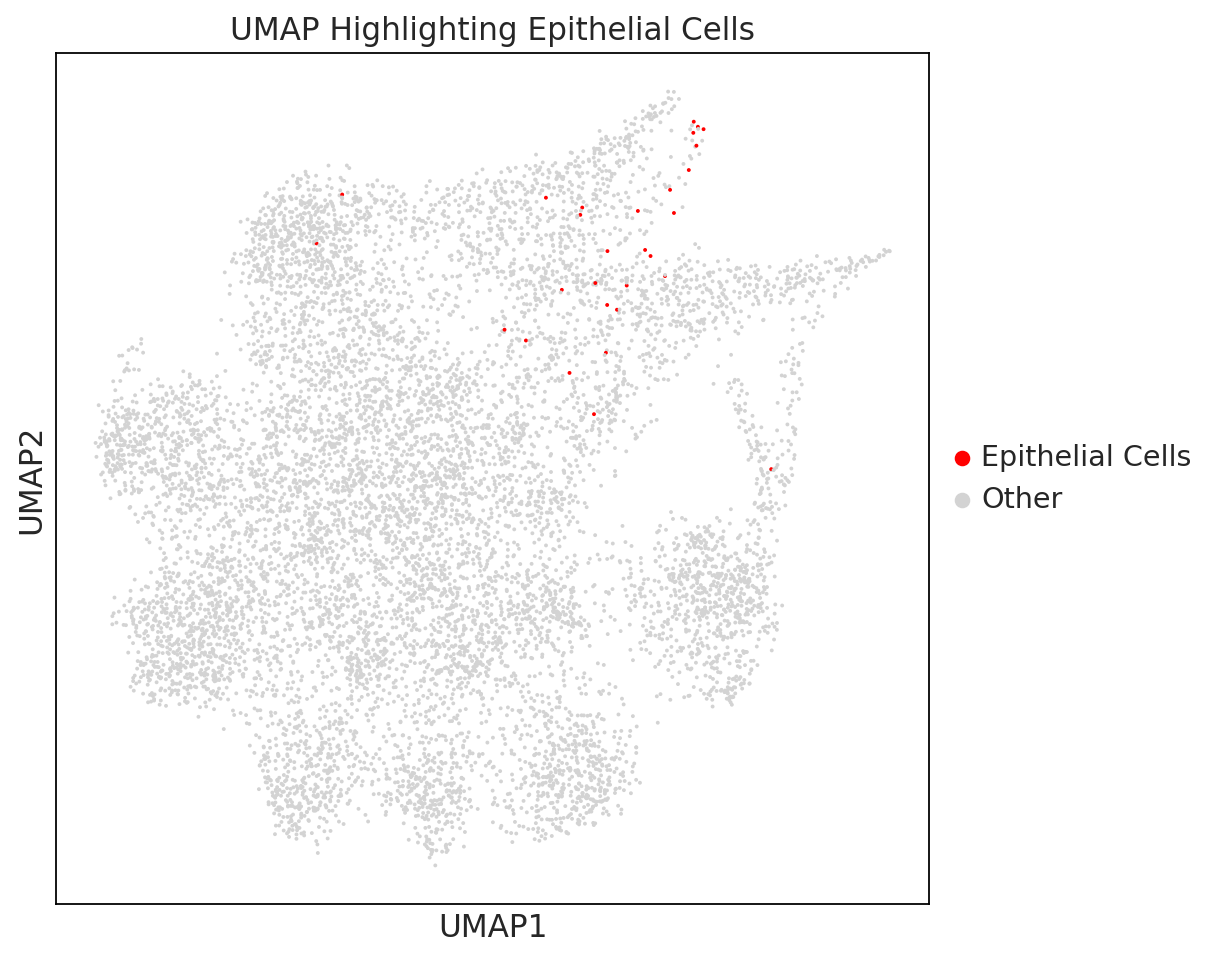

... storing 'highlight' as categorical


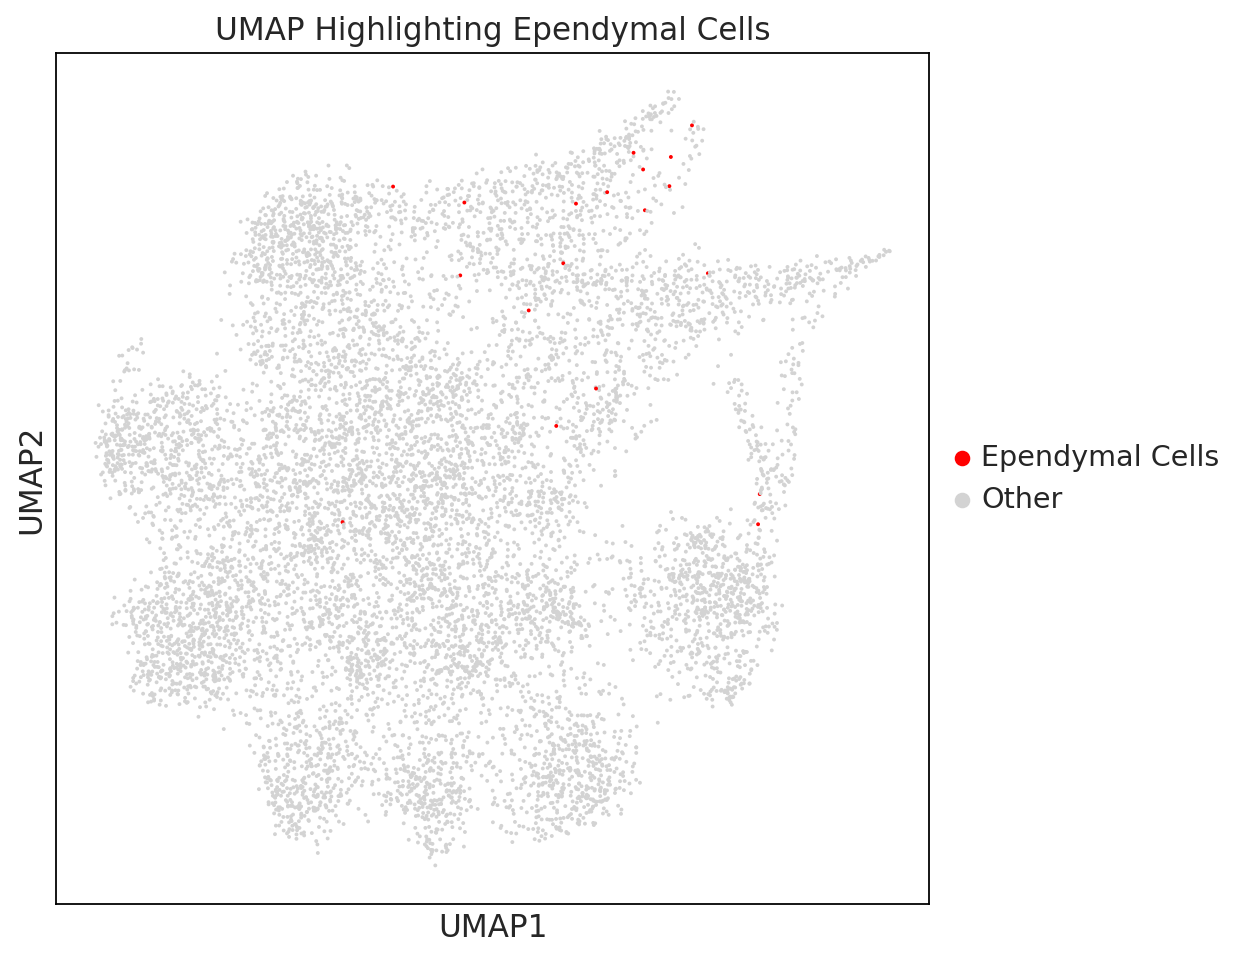

In [28]:
# Get the unique cell types
unique_cell_types = splice_adata.obs["Cleaned_cluster_name"].unique()

# Loop through each cell type and create a UMAP plot
for cell_type in unique_cell_types:
    # Create a new column where all other cell types are labeled as 'Other'
    splice_adata.obs["highlight"] = splice_adata.obs["Cleaned_cluster_name"].astype(str)
    splice_adata.obs.loc[splice_adata.obs["highlight"] != cell_type, "highlight"] = "Other"

    # Define color palette (highlighted cell type in red, others in gray)
    palette = {"Other": "lightgray", cell_type: "red"}

    # Plot the UMAP
    sc.pl.umap(splice_adata, color="highlight", palette=palette, 
               title=f"UMAP Highlighting {cell_type}", show=False)

    # Show 
    plt.show()

### Identify cell waypoints using splicing based PCs!

In [29]:
# Define possible number of waypoints to learn
n_waypoints_learn = [30, 100]

# Placeholder to store waypoints and metacell dictionaries for each n_waypoints
waypoints_dict = {}
metacell_dicts = {}

# Parameters
num_components = 30  # Number of components to consider
metacell_size = 10    # Number of nearest cells to assign to each waypoint
pca_components = splice_adata.obsm["X_pca"]

# Loop over different n_waypoints to generate waypoints and metacell assignments
for n_waypoints in n_waypoints_learn:

    print(f"Finding {n_waypoints} waypoints from the PCA components!")
    random_seed = np.random.randint(0, 10000 + 1)  # Generate random seed
    
    # Max-min sampling to identify waypoints
    waypoints = wayp.max_min_sampling(pca_components, n_waypoints, num_components=num_components, seed=random_seed)
    
    # Store waypoints for this particular number of waypoints
    waypoints_dict[n_waypoints] = waypoints

    # Assign nearest cells to each waypoint (metacells)
    metacell_dict = wayp.assign_nearest_cells(waypoints, pca_components, num_nearest=metacell_size)
    
    # Store the metacell dictionary for this number of waypoints
    metacell_dicts[n_waypoints] = metacell_dict

Finding 30 waypoints from the PCA components!
Finding 100 waypoints from the PCA components!


#### Try looking at waypoints just using PC space...

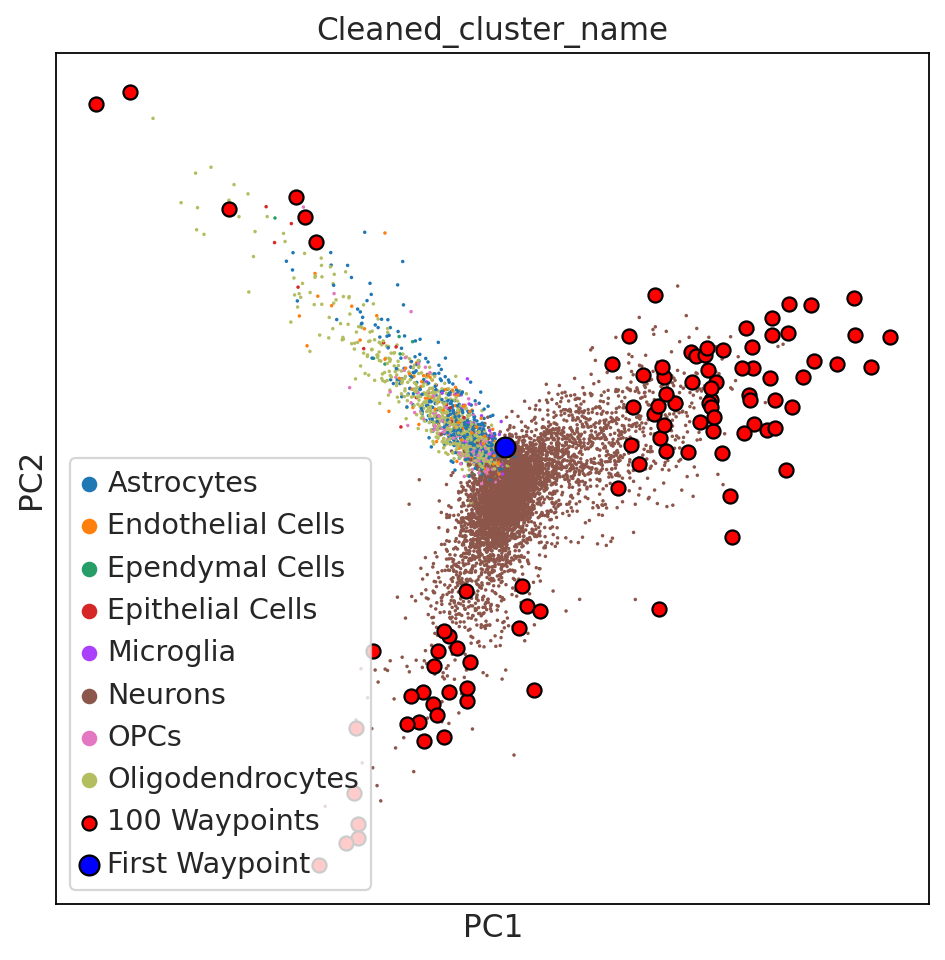

In [32]:
wayp.plot_PCA_with_waypoints(splice_adata, waypoints_dict, n_waypoints=100, waypoint_color='red', first_waypoint_color='blue', size=10, color_by='Cleaned_cluster_name')

### Generate_initializations matrices for Phi and Psi

In [33]:
rho_hat = splice_adata.layers["junc_ratio"]

# Generate multiple initializations
psi_initializations, phi_initializations = wayp.generate_initializations(rho_hat, waypoints_dict, metacell_dicts, epsilon=0.001)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Finding 30 waypoints from the diffusion components!


30it [00:01, 19.47it/s]


Finding 100 waypoints from the diffusion components!


100it [00:04, 20.68it/s]


In [34]:
# Loop through the waypoints_dict and corresponding initializations
for i, n_waypoints in enumerate(waypoints_dict.keys()):

    print(f"Adding waypoint based initializations to anndata for {n_waypoints} waypoints!")

    # Extract the corresponding psi and phi initializations
    psi = psi_initializations[i]
    phi = phi_initializations[i]

    # Convert psi and phi to torch tensors if needed
    psi = torch.tensor(psi)
    phi = torch.tensor(phi)

    # Convert to NumPy arrays if psi and phi are torch tensors (just in case)
    if isinstance(psi, torch.Tensor):
        psi = psi.cpu().numpy()  # Convert to NumPy array
    if isinstance(phi, torch.Tensor):
        phi = phi.cpu().numpy()  # Convert to NumPy array

    # Store psi in `adata.varm` and phi in `adata.obsm` with keys based on the number of waypoints
    splice_adata.varm[f'psi_init_{n_waypoints}_waypoints'] = psi  # Store psi with name 'psi_init_{n_waypoints}_waypoints'
    splice_adata.obsm[f'phi_init_{n_waypoints}_waypoints'] = phi  # Store phi with name 'phi_init_{n_waypoints}_waypoints'


Adding waypoint based initializations to anndata for 30 waypoints!
Adding waypoint based initializations to anndata for 100 waypoints!


In [35]:
# remove junc_ratio layer from splice_adata to save memory prior to saving object 
splice_adata.layers.pop("junc_ratio")

<COOrdinate sparse matrix of dtype 'float64'
	with 7641130 stored elements and shape (9904, 13402)>

### Save splice_adata Anndata object

In [36]:
# remove first old_junction_id_index column from splice_adata.var
splice_adata.var.drop(columns=['old_junction_id_index'], inplace=True)

In [38]:
import datetime
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

output_dir="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/junction_processing_20250223/anndatas"

# in file name include timestamp 
new_filename = f"Easysci_RH_Anndata_ATSE_counts_with_waypoints_{timestamp}.h5ad"

# Create the new full file path
new_file_path = os.path.join(output_dir, new_filename)

# Save the AnnData object with the new filename
splice_adata.write_h5ad(new_file_path, compression='gzip')

print(f"AnnData saved as {new_file_path}")

AnnData saved as /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/ATSEmap/RH/output/junction_processing_20250223/anndatas/Easysci_RH_Anndata_ATSE_counts_with_waypoints_20250303_170503.h5ad
